# Calculation of the number of waterbody polygons that straddle tiles of various sizes
- the large number of tiles and polygons (~700500) make this a slow process if 'spatial' tests are used. 
- calculate inclusion if the ll and ur corners of the bounding box are in a single tile
- ll and ur are calculated using geometry.bounds
- made efficient by just testing the bounding box against the tile parmeters
#### Q1: Edge cases v. tile size. 
- How many polygons are 'missed' if we process by tiles, and how does that reduce if the tiles are larger/smaller?
#### Q2: The efficacy of overlap processing
- For a give tile size, if we run again with offset tiles (say 0.5 of the tile size across, 0.5 down), what is left?


In [268]:
import matplotlib.pyplot as plt

from deafrica_tools.plotting import display_map
from deafrica_tools.waterbodies import (
    get_geohashes,
    get_waterbodies,
    get_waterbody,
    get_time_series,
    display_time_series,
    plot_last_valid_obs
)
import geopandas as gp
import os
import xarray as xr
import numpy as np
import pandas as pd

In [461]:
results_directory = '/home/jovyan/deafrica_water_quality/wq_results/'
results_filename = 'wb_tile_analysis.csv'
results_figname = 'wb_tile_graph'

In [5]:
# global parmeters
Xmin = -18
Ymin = -35.5
Xmax = 52
Ymax = 38
Bbox = (Xmin,Ymin,Xmax,Ymax)
all_waterbodies = get_waterbodies(Bbox, crs="EPSG:4326")

##### this is a simple / smart approach

In [458]:
#set up a file for the results
resultsfile = results_directory + results_filename

if not os.path.exists(resultsfile) or True:
    results = pd.DataFrame(
    )
    results.index = all_waterbodies.index
    results.to_csv(resultsfile)
else:
    results = pd.read_csv(resultsfile,index_col=0)


wbs = all_waterbodies[0:].geometry.bounds.to_xarray()
wbs['n'] = ('index'),np.zeros((wbs.index.size),'int')


In [459]:

for tilesize in [0.1,0.2,0.25,0.35,0.5,0.75,1.0]:
    tilesizename = 't_'+str(tilesize)
    results[tilesizename] = np.ones((len(results)),'int') + 10000
    tileoffsets = {
        'a':np.array([0,0]),
        'b':np.array([.5,.5]),
        'c':np.array([.5,0]),
        'd':np.array([0,.5])}

    for offset in tileoffsets.keys():
        delta = tileoffsets[offset] * tilesize
    
        colname = 't'+offset+'_'+str(tilesize)
        results[colname] = np.zeros((len(results)),'int')
        
        wbs['tx0'] = ((wbs['minx'] + delta[0])/tilesize).astype('int')
        wbs['ty0'] = ((wbs['miny'] + delta[1])/tilesize).astype('int')
        wbs['tx1'] = ((wbs['maxx'] + delta[0])/tilesize).astype('int')
        wbs['ty1'] = ((wbs['maxy'] + delta[1])/tilesize).astype('int')
    
        # n is the number of cells that overlap with the bounding box 
        # of the polygon. For n>2, it can be an overestimate of the number of tiles 
        # covered by the actual polygon. n==1, the main case, is accurately counted.
        
        wbs['n'] = ((wbs.tx1-wbs.tx0) + 1) * ((wbs.ty1-wbs.ty0) + 1)
    
        # this will get the min value of the columns 
        results[colname] = wbs.n
        results[colname] = \
            results[[tilesizename,colname]].to_xarray()[[tilesizename,colname]].to_array().min(axis=0)

        # this overall result after 4 passes is redundant : it is the same as result 'd'
        results[tilesizename] = \
            results[[tilesizename,colname]].to_xarray()[[tilesizename,colname]].to_array().min(axis=0)
    

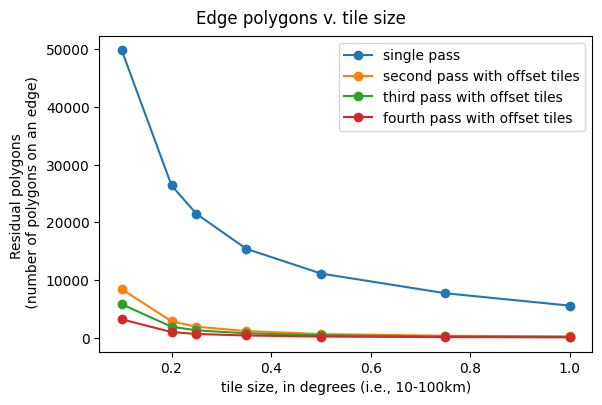

In [465]:
fig, axes = plt.subplots(1,1,sharex=False, sharey=False, layout="constrained")    
cm = 1/2.54
fig.set_size_inches(15*cm,10*cm)
fig.suptitle('Edge polygons v. tile size')
ax = axes
ax.set_ylabel ('Residual polygons \n (number of polygons on an edge)')
ax.set_xlabel ('tile size, in degrees (i.e., 10-100km)')
for option in (['a','b','c','d']) :
    if option == 'a': label = 'single pass'
    if option == 'b': label = 'second pass with offset tiles'
    if option == 'c': label = 'third pass with offset tiles'
    if option == 'd': label = 'fourth pass with offset tiles'
    datavalues = []
    tilesizes  = [0.1,0.2,0.25,0.35,0.5,0.75,1.0]
    for tilesize in tilesizes :
        var = 't' + option + '_' + str(tilesize)
        datavalues = np.append(datavalues,\
                               results.loc[results[var]!=1][var].count())
    plt.plot(tilesizes,datavalues,
             marker='o',
             label=label)
    ax.legend(loc='upper right')
plt.savefig(results_directory+results_figname,format='pdf')
plt.show()
    
                      
        

### below is a dumb approach, but not the dumbest I've tried
- this is using xarray.sel using the centroids and bounding box coordinates of the polygons to query an array representing tiles.
- the process cannnot be run all at once because the query creates an in-memory array of size tiles * waterbodies, so it has to go in batches of waterbodies. Its slow to run this for multiple tile sizes and with 4 offset patterns, and the basic logic is identical to above. 
- another even dumber (more brute-force) approach was to iterate through the tiles one by one testing against the waterbodies using the geopandas.within function to test the polygon. That process at least speeds up as waterbodies are eliminated from the list.
- combinations and refinements of the above are possible but they will all give similar results ... eventually.
- 

In [466]:
all_waterbodies.geometry.bounds.head(1)

,minx,miny,maxx,maxy
0,23.0355,-18.2743,23.0361,-18.2735


In [468]:
tilesize = 1.0 # degrees
tileoffset = (0,0)
included_var = 'wb_included_'+str(tilesize)
centroid_var = 'wb_centroid_'+str(tilesize)
results_filename = 'wb_tile_analysis_method2.csv'



In [469]:
xcoords = xr.Coordinates({'x' : np.arange(Xmin,Xmax,tilesize)})
ycoords = xr.Coordinates({'y' : np.arange(Ymin,Ymax,tilesize)})

tilenames = np.zeros((ycoords.sizes['y'],xcoords.sizes['x']),'str')

blank = xr.DataArray(data = tilenames,
            coords = {'y': np.arange(Ymin,Ymax,tilesize),
                      'x': np.arange(Xmin,Xmax,tilesize)},
            dims = ['y','x'],
            name = 'x_y'
            )
ds = xr.Dataset(data_vars = {'x_y' : blank})
ds['x_y'] = ds.x_y + ds.x.astype('str') + '_' + ds.y.astype('str')

ds[included_var] = ('y','x'),np.zeros(ds.x_y.shape)
ds[centroid_var] = ('y','x'),np.zeros(ds.x_y.shape) 

delta = 50000
end   = len(all_waterbodies)
#end   = 20000
for i in np.arange(0,end,delta):
    j = i + delta
    if j > end : j = end
    print(np.round(100* i/end,1),' %')

    wbs = all_waterbodies[i:j].geometry.bounds

    #reatain results as a dataset to facilitate joins ..
    centroid_tiles = ds.sel(
        x= 0.5 * (wbs['minx'] + wbs['maxx']).to_xarray(),
        y= 0.5 * (wbs['miny'] + wbs['maxy']).to_xarray(),
        method='nearest')
    
    wbs['centroid_tile'] = centroid_tiles.x_y

    ds[centroid_var] = \
    ds[centroid_var] + \
        ds.where(ds.x_y == centroid_tiles.x_y)['x_y'].count(dim='index')

    include_tiles = \
        ds.sel(
        x= wbs['minx'].to_xarray(),
        y= wbs['miny'].to_xarray(),
        method='nearest')
    
    include_tiles['ll'] = include_tiles.x_y
    
    include_tiles['ur'] = \
        ds.sel(
        x= wbs['maxx'].to_xarray(),
        y= wbs['maxy'].to_xarray(),
        method='nearest').x_y
    
    include_tiles['tile'] = \
        include_tiles.ll.where(include_tiles.ll == include_tiles.ur)
    
    wbs['included_tile'] = include_tiles.tile
    
    ds[included_var] = \
    ds[included_var] + \
        ds.where(ds.x_y== include_tiles.tile)['x_y'].count(dim='index')

0.0  %
7.1  %
14.3  %
21.4  %
28.5  %
35.7  %
42.8  %
50.0  %
57.1  %
64.2  %
71.4  %
78.5  %
85.6  %
92.8  %
99.9  %


In [470]:
total_wbs    = ds[centroid_var].sum().item() 
included_wbs = ds[included_var].sum().item()
tile_count = ds.where(ds[centroid_var] > 0).x_y.count().item()
resultsfile = results_directory + results_filename
if os.path.exists(resultsfile):
    results = pd.read_csv(resultsfile,index_col=0)
else:
    results = pd.DataFrame(
        columns = ['tile_size','water_tiles','wb_total','wb_included']
    )
    results.to_csv(resultsfile)
    

result = (tilesize,tile_count,total_wbs,included_wbs)
#results.loc[len(results)] = result
results.loc[0] = result
results

,tile_size,water_tiles,wb_total,wb_included
0,1.0,2230.0,700689.0,694911.0


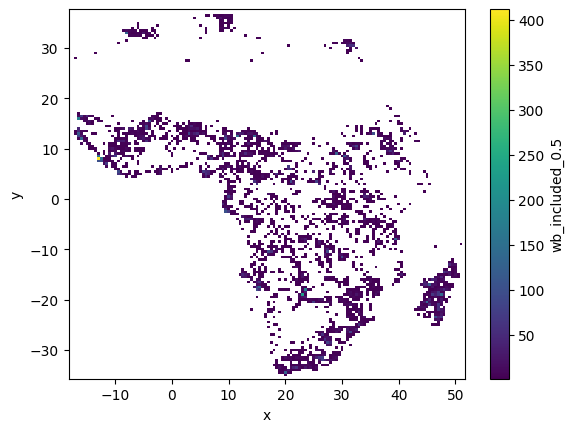

In [293]:
ds.where(ds[included_var]>0)[included_var].plot()